In [ ]:
https://raw.githubusercontent.com/BryanJimenezUtec/Caso-Practico/refs/heads/main/Dataset/Prestige_modificado.csv

In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv('https://raw.githubusercontent.com/BryanJimenezUtec/Caso-Practico/refs/heads/main/Dataset/Prestige_modificado.csv', sep=';')

In [ ]:
print(df.shape)
print(df.head())

(102, 7)
            occupation  education  income  women  prestige  census  type_num
0   gov.administrators      13.11   12351  11.16      68.8    1113         1
1     general.managers      12.26   25879   4.02      69.1    1130         1
2          accountants      12.77    9271  15.70      63.4    1171         1
3  purchasing.officers      11.42    8865   9.11      56.8    1175         1
4             chemists      14.62    8403  11.68      73.5    2111         1


In [ ]:
print(df.info())
print(df.isnull().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102 entries, 0 to 101
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   occupation  102 non-null    object 
 1   education   102 non-null    float64
 2   income      102 non-null    int64  
 3   women       102 non-null    float64
 4   prestige    102 non-null    float64
 5   census      102 non-null    int64  
 6   type_num    102 non-null    int64  
dtypes: float64(3), int64(3), object(1)
memory usage: 5.7+ KB
None
occupation    0
education     0
income        0
women         0
prestige      0
census        0
type_num      0
dtype: int64


In [ ]:
print(df.duplicated().sum())
print(df.describe())


0
        education        income       women    prestige       census  \
count  102.000000    102.000000  102.000000  102.000000   102.000000   
mean    10.738039   6797.901961   28.979020   46.833333  5401.774510   
std      2.728444   4245.922227   31.724931   17.204486  2644.993215   
min      6.380000    611.000000    0.000000   14.800000  1113.000000   
25%      8.445000   4106.000000    3.592500   35.225000  3120.500000   
50%     10.540000   5930.500000   13.600000   43.600000  5135.000000   
75%     12.647500   8187.250000   52.202500   59.275000  8312.500000   
max     15.970000  25879.000000   97.510000   87.200000  9517.000000   

         type_num  
count  102.000000  
mean     1.843137  
std      0.817447  
min      0.000000  
25%      1.000000  
50%      2.000000  
75%      2.000000  
max      3.000000  


In [ ]:
variables_numericas = df.select_dtypes(include=['int64', 'float64'])
matriz_correlacion = variables_numericas.corr()

print(matriz_correlacion.round(3))
print(matriz_correlacion['prestige'].sort_values(ascending=False).round(3))


           education  income  women  prestige  census  type_num
education      1.000   0.578  0.062     0.850  -0.823    -0.382
income         0.578   1.000 -0.441     0.715  -0.361    -0.368
women          0.062  -0.441  1.000    -0.118  -0.227     0.251
prestige       0.850   0.715 -0.118     1.000  -0.635    -0.465
census        -0.823  -0.361 -0.227    -0.635   1.000     0.288
type_num      -0.382  -0.368  0.251    -0.465   0.288     1.000
prestige     1.000
education    0.850
income       0.715
women       -0.118
type_num    -0.465
census      -0.635
Name: prestige, dtype: float64


In [ ]:
import matplotlib.pyplot as plt

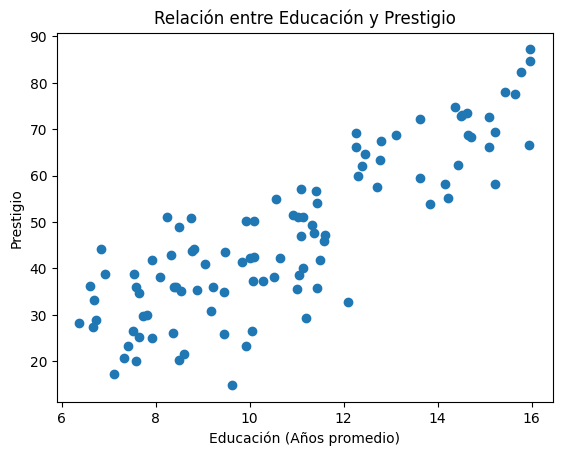

In [ ]:


# Gráfica 1: Educación vs Prestigio
plt.figure()
plt.scatter(df['education'], df['prestige'])
plt.xlabel('Educación (Años promedio)')
plt.ylabel('Prestigio')
plt.title('Relación entre Educación y Prestigio')
plt.show()



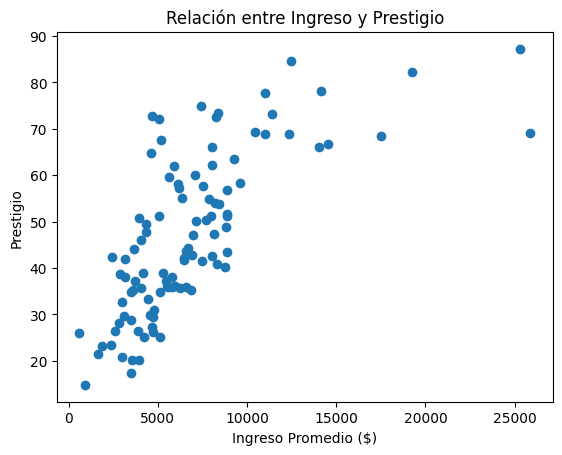

In [ ]:
# Gráfica 2: Ingreso vs Prestigio
plt.figure()
plt.scatter(df['income'], df['prestige'])
plt.xlabel('Ingreso Promedio ($)')
plt.ylabel('Prestigio')
plt.title('Relación entre Ingreso y Prestigio')
plt.show()


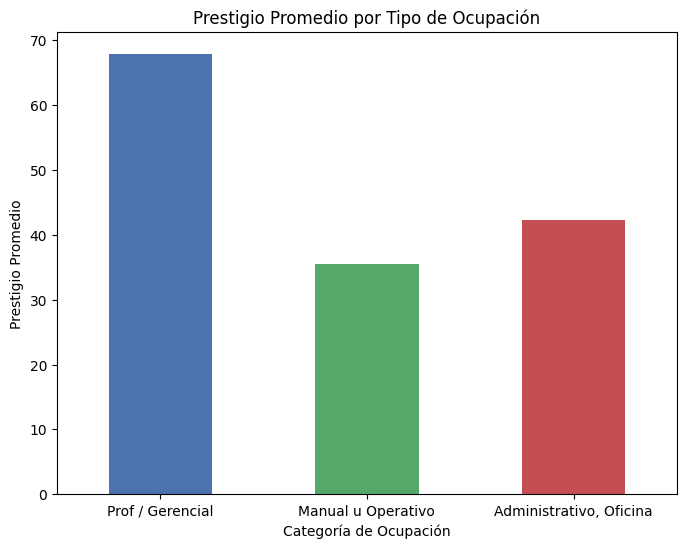

In [ ]:
# Gráfica 3: Prestigio Promedio por Tipo de Ocupación (Versión Mejorada)
plt.figure(figsize=(8, 6))
# Calculamos el prestigio promedio agrupando por 'type_num'
promedio_prestigio_tipo = df.groupby('type_num')['prestige'].mean()
# Filtramos el tipo 0
if 0 in promedio_prestigio_tipo:
    promedio_prestigio_tipo = promedio_prestigio_tipo.drop(0)
# Creamos el gráfico de barras
promedio_prestigio_tipo.plot(kind='bar', color=['#4C72B0', '#55A868', '#C44E52'])

# Reemplazamos los números por los nombres reales
nombres_grupos = ['Prof / Gerencial', 'Manual u Operativo', 'Administrativo, Oficina']
plt.xticks(ticks=[0, 1, 2], labels=nombres_grupos, rotation=0)

plt.xlabel('Categoría de Ocupación')
plt.ylabel('Prestigio Promedio')
plt.title('Prestigio Promedio por Tipo de Ocupación')

plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [ ]:
# 1. Seleccionamos las columnas con los nombres exactos del CSV
columnas_cluster = ['education', 'income', 'women', 'prestige', 'type_num']
X = df[columnas_cluster].copy()

In [ ]:
# 2. Escalar los datos (Crucial para que los ingresos no opaquen la educación)
escalador = StandardScaler()
X_escalado = escalador.fit_transform(X)

In [ ]:
# 3. Ejecutar K-Means con 4 clústeres
modelo_k4 = KMeans(n_clusters=4, random_state=42, n_init=10)
df['Cluster_4'] = modelo_k4.fit_predict(X_escalado)

In [ ]:
# 4. Ejecutar K-Means con 5 clústeres
modelo_k5 = KMeans(n_clusters=5, random_state=42, n_init=10)
df['Cluster_5'] = modelo_k5.fit_predict(X_escalado)

# 5. Imprimir los centroides
print("--- Modelo con 4 Clústeres ---")
print(df.groupby('Cluster_4')[columnas_cluster].mean().round(2))
print("\n--- Modelo con 5 Clústeres ---")
print(df.groupby('Cluster_5')[columnas_cluster].mean().round(2))

--- Modelo con 4 Clústeres ---
           education    income  women  prestige  type_num
Cluster_4                                                
0              13.59   7329.35  36.35     63.33      0.95
1               8.82   5878.74   9.60     37.26      2.09
2              10.12   3545.04  74.16     37.76      2.57
3              14.69  15746.83   6.00     74.23      1.00

--- Modelo con 5 Clústeres ---
           education    income  women  prestige  type_num
Cluster_5                                                
0              10.94   3909.12  73.76     41.50      2.88
1               9.31   6922.03   5.84     42.18      2.25
2              13.59   7329.35  36.35     63.33      0.95
3               7.78   3327.48  34.10     26.87      1.71
4              14.69  15746.83   6.00     74.23      1.00
